# Binary Classification with Spark Batch Trainer

This notebook provides a reproducible, end-to-end comparison of **XGBoost**, **CatBoost**, and **LightGBM** on a binary diabetes dataset. It follows the current public API and keeps data preparation, training, and final evaluation clearly separated.

## Learning objectives

By the end of the notebook, you will be able to:

- prepare stratified train, validation, and test datasets;
- convert only training and validation inputs to Spark DataFrames;
- configure the three supported model backends;
- inspect batch-level training history; and
- compare final results on an untouched test set.

> **Memory boundary:** Spark creates and filters batches, but each batch and the complete validation set are collected on the Python driver.

## Phase 1 — Environment and reproducibility

The bootstrap below works whether the notebook server starts from the repository root or from the `notebooks/` directory. It makes the `src/` layout explicit instead of relying on hidden environment state.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Return the nearest parent containing the project configuration."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate pyproject.toml from the current directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = PROJECT_ROOT / "src"
for import_path in (PROJECT_ROOT, SRC_PATH):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer


In [2]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
from pyspark.sql import SparkSession

from sklearn.model_selection import train_test_split

from spark_batch_trainer import create_trainer
from utils import (
    load_dataset,
    make_results_df,
    plot_binary_confusion_matrices,
    get_dataset_path,
    preprocess_splits,
    stratified_split_dataset,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
TARGET_COLUMN = "diabetes"
MAX_ROWS = None  # Set an integer only for a deliberately bounded smoke run.

## Phase 2 — Load and validate the dataset

This phase performs inexpensive quality checks before Spark or any model SDK is started. The optional row limit keeps the tutorial practical on a laptop; production experiments should size batches from measured driver capacity.

In [3]:
dataset_path = get_dataset_path("data/big_binary_dataset")

print("Loading dataset...")
print("Dataset path:", dataset_path)
dataset = load_dataset(dataset_path)

if MAX_ROWS is not None and len(dataset) > MAX_ROWS:
    dataset, _ = train_test_split(
        dataset,
        train_size=MAX_ROWS,
        stratify=dataset[TARGET_COLUMN],
        random_state=RANDOM_STATE,
    )
    dataset = dataset.reset_index(drop=True)

assert TARGET_COLUMN in dataset.columns, f"Missing target column: {TARGET_COLUMN}"
assert dataset[TARGET_COLUMN].nunique() == 2, "A binary target was expected."
assert not dataset.columns.duplicated().any(), "Duplicate column names detected."

quality_summary = pd.DataFrame(
    {
        "rows": [len(dataset)],
        "features": [dataset.shape[1] - 1],
        "missing_values": [int(dataset.isna().sum().sum())],
        "duplicate_rows": [int(dataset.duplicated().sum())],
        "positive_rate": [float(dataset[TARGET_COLUMN].mean())],
    }
)
display(quality_summary)
display(dataset.head())

Loading dataset...
Dataset path: /Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/data/big_binary_dataset/binary_diabetes_dataset.csv


,rows,features,missing_values,duplicate_rows,positive_rate
0,100000,8,0,3854,0.085


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### Interpretation checkpoint

Confirm that the target has two classes, review the positive-class rate, and investigate missing or duplicated observations before continuing. A stratified split preserves the observed class ratio but does not correct data-quality issues.

## Phase 3 — Create train, validation, and test splits

The validation set is used during batch training. The test set remains outside the trainer and is evaluated only after each final model has been selected.

In [4]:
train_df, validation_df, test_df = stratified_split_dataset(
    dataset,
    target_column=TARGET_COLUMN,
    train_ratio=0.60,
    valid_ratio=0.20,
    test_ratio=0.20,
    random_state=123,
)

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(frame),
            "positive_rate": frame[TARGET_COLUMN].mean(),
        }
        for name, frame in (
            ("train", train_df),
            ("validation", validation_df),
            ("test", test_df),
        )
    ]
)
display(split_summary)

splits, target_encoder = preprocess_splits(
    train_df, validation_df, test_df,
    target_column=TARGET_COLUMN,
    y_dtype="int",
    auto_encode_target=True,
)
X_train, y_train = splits.X_train, splits.y_train
X_valid, y_valid = splits.X_valid, splits.y_valid
X_test, y_test = splits.X_test, splits.y_test
print(f"Categorical features: {splits.cat_cols}")
print(f"Target classes: {target_encoder.classes_.tolist()}")

,split,rows,positive_rate
0,train,60000,0.085
1,validation,20000,0.085
2,test,20000,0.085


Categorical features: ['gender', 'smoking_history']
Target classes: [0, 1]


## Phase 4 — Start Spark and prepare trainer inputs

Only train and validation are converted to Spark because the library consumes Spark inputs for fitting. Test data stays in pandas for bounded native-model evaluation.

In [5]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SparkBatchTrainerBinaryGuide")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

spark_train_df = spark.createDataFrame(
    pd.concat([X_train, y_train.rename(TARGET_COLUMN)], axis=1)
)
spark_validation_df = spark.createDataFrame(
    pd.concat([X_valid, y_valid.rename(TARGET_COLUMN)], axis=1)
)

print(f"Spark version: {spark.version}")
print(f"Training rows: {spark_train_df.count():,}")
print(f"Validation rows: {spark_validation_df.count():,}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/05 08:00:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


Training rows: 60,000


Validation rows: 20,000


## Phase 5 — Shared configuration and evaluation helpers

All backends use the same batch-level controls. Model hyperparameters remain backend-specific because the native SDKs use different vocabularies.

In [6]:
TRAINING_CONFIG = {
    "num_batches": 5,
    "max_patience": 3,
    "metric_mode": "min",
    "min_delta": 1e-4,
    "use_sample_weight": True,
    "show_learning_curve": True,
}

LEARNING_RATE_CONFIG = {
    "initial_lr": 0.05,
    "decay_rate": 0.65,
    "min_lr": 0.005,
}

In [7]:


def summarize_history(trainer) -> pd.DataFrame:
    """Flatten the final metric value recorded for every batch."""
    history = trainer.get_training_history()
    return pd.DataFrame(
        {
            "batch": history.batch_numbers,
            "train_metric": [values[-1] for values in history.train_scores],
            "validation_metric": [
                values[-1] for values in history.validation_scores
            ],
        }
    )

## Phase 6 — Train XGBoost

XGBoost uses binary logistic loss. The optional learning-rate policy updates the rate between Spark batches.

[0]	validation_0-logloss:0.65695	validation_1-logloss:0.65776
[1]	validation_0-logloss:0.62470	validation_1-logloss:0.62580
[2]	validation_0-logloss:0.59868	validation_1-logloss:0.60111
[3]	validation_0-logloss:0.57751	validation_1-logloss:0.58032
[4]	validation_0-logloss:0.55395	validation_1-logloss:0.55649
[5]	validation_0-logloss:0.53516	validation_1-logloss:0.53873
[6]	validation_0-logloss:0.51876	validation_1-logloss:0.52286
[7]	validation_0-logloss:0.50281	validation_1-logloss:0.50764
[8]	validation_0-logloss:0.48384	validation_1-logloss:0.48871
[9]	validation_0-logloss:0.46477	validation_1-logloss:0.47033
[10]	validation_0-logloss:0.44835	validation_1-logloss:0.45408
[11]	validation_0-logloss:0.43199	validation_1-logloss:0.43825
[12]	validation_0-logloss:0.41785	validation_1-logloss:0.42431
[13]	validation_0-logloss:0.40769	validation_1-logloss:0.41458
[14]	validation_0-logloss:0.39608	validation_1-logloss:0.40368
[15]	validation_0-logloss:0.38406	validation_1-logloss:0.39189
[1

[0]	validation_0-logloss:0.23213	validation_1-logloss:0.22616
[1]	validation_0-logloss:0.23072	validation_1-logloss:0.22522
[2]	validation_0-logloss:0.22925	validation_1-logloss:0.22383
[3]	validation_0-logloss:0.22749	validation_1-logloss:0.22221
[4]	validation_0-logloss:0.22595	validation_1-logloss:0.22111
[5]	validation_0-logloss:0.22459	validation_1-logloss:0.21991
[6]	validation_0-logloss:0.22330	validation_1-logloss:0.21879
[7]	validation_0-logloss:0.22185	validation_1-logloss:0.21775
[8]	validation_0-logloss:0.22063	validation_1-logloss:0.21668
[9]	validation_0-logloss:0.21969	validation_1-logloss:0.21647
[10]	validation_0-logloss:0.21848	validation_1-logloss:0.21583
[11]	validation_0-logloss:0.21722	validation_1-logloss:0.21495
[12]	validation_0-logloss:0.21605	validation_1-logloss:0.21434
[13]	validation_0-logloss:0.21525	validation_1-logloss:0.21366
[14]	validation_0-logloss:0.21441	validation_1-logloss:0.21298
[15]	validation_0-logloss:0.21312	validation_1-logloss:0.21177
[1

[0]	validation_0-logloss:0.18372	validation_1-logloss:0.19383
[1]	validation_0-logloss:0.18324	validation_1-logloss:0.19361
[2]	validation_0-logloss:0.18273	validation_1-logloss:0.19343
[3]	validation_0-logloss:0.18231	validation_1-logloss:0.19321
[4]	validation_0-logloss:0.18162	validation_1-logloss:0.19302
[5]	validation_0-logloss:0.18122	validation_1-logloss:0.19287
[6]	validation_0-logloss:0.18088	validation_1-logloss:0.19267
[7]	validation_0-logloss:0.18048	validation_1-logloss:0.19247
[8]	validation_0-logloss:0.18013	validation_1-logloss:0.19231
[9]	validation_0-logloss:0.17971	validation_1-logloss:0.19211
[10]	validation_0-logloss:0.17917	validation_1-logloss:0.19191
[11]	validation_0-logloss:0.17882	validation_1-logloss:0.19175
[12]	validation_0-logloss:0.17847	validation_1-logloss:0.19153
[13]	validation_0-logloss:0.17801	validation_1-logloss:0.19142
[14]	validation_0-logloss:0.17740	validation_1-logloss:0.19130
[15]	validation_0-logloss:0.17705	validation_1-logloss:0.19113
[1

[0]	validation_0-logloss:0.18846	validation_1-logloss:0.18790
[1]	validation_0-logloss:0.18815	validation_1-logloss:0.18781
[2]	validation_0-logloss:0.18771	validation_1-logloss:0.18769
[3]	validation_0-logloss:0.18746	validation_1-logloss:0.18764
[4]	validation_0-logloss:0.18717	validation_1-logloss:0.18763
[5]	validation_0-logloss:0.18669	validation_1-logloss:0.18761
[6]	validation_0-logloss:0.18644	validation_1-logloss:0.18756
[7]	validation_0-logloss:0.18606	validation_1-logloss:0.18749
[8]	validation_0-logloss:0.18562	validation_1-logloss:0.18749
[9]	validation_0-logloss:0.18505	validation_1-logloss:0.18742
[10]	validation_0-logloss:0.18465	validation_1-logloss:0.18734
[11]	validation_0-logloss:0.18439	validation_1-logloss:0.18732
[12]	validation_0-logloss:0.18398	validation_1-logloss:0.18727
[13]	validation_0-logloss:0.18375	validation_1-logloss:0.18721
[14]	validation_0-logloss:0.18337	validation_1-logloss:0.18719
[15]	validation_0-logloss:0.18298	validation_1-logloss:0.18712
[1

[0]	validation_0-logloss:0.19070	validation_1-logloss:0.18601
[1]	validation_0-logloss:0.19032	validation_1-logloss:0.18596
[2]	validation_0-logloss:0.18989	validation_1-logloss:0.18586
[3]	validation_0-logloss:0.18966	validation_1-logloss:0.18583
[4]	validation_0-logloss:0.18923	validation_1-logloss:0.18577
[5]	validation_0-logloss:0.18884	validation_1-logloss:0.18574
[6]	validation_0-logloss:0.18857	validation_1-logloss:0.18570
[7]	validation_0-logloss:0.18818	validation_1-logloss:0.18561
[8]	validation_0-logloss:0.18785	validation_1-logloss:0.18559
[9]	validation_0-logloss:0.18756	validation_1-logloss:0.18556
[10]	validation_0-logloss:0.18722	validation_1-logloss:0.18554
[11]	validation_0-logloss:0.18688	validation_1-logloss:0.18549
[12]	validation_0-logloss:0.18651	validation_1-logloss:0.18546
[13]	validation_0-logloss:0.18619	validation_1-logloss:0.18543
[14]	validation_0-logloss:0.18591	validation_1-logloss:0.18536
[15]	validation_0-logloss:0.18547	validation_1-logloss:0.18531
[1

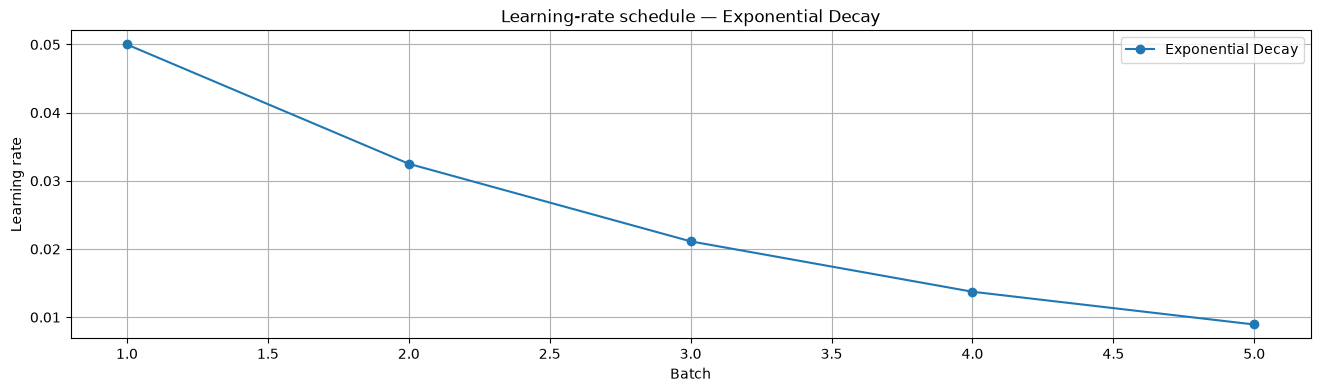

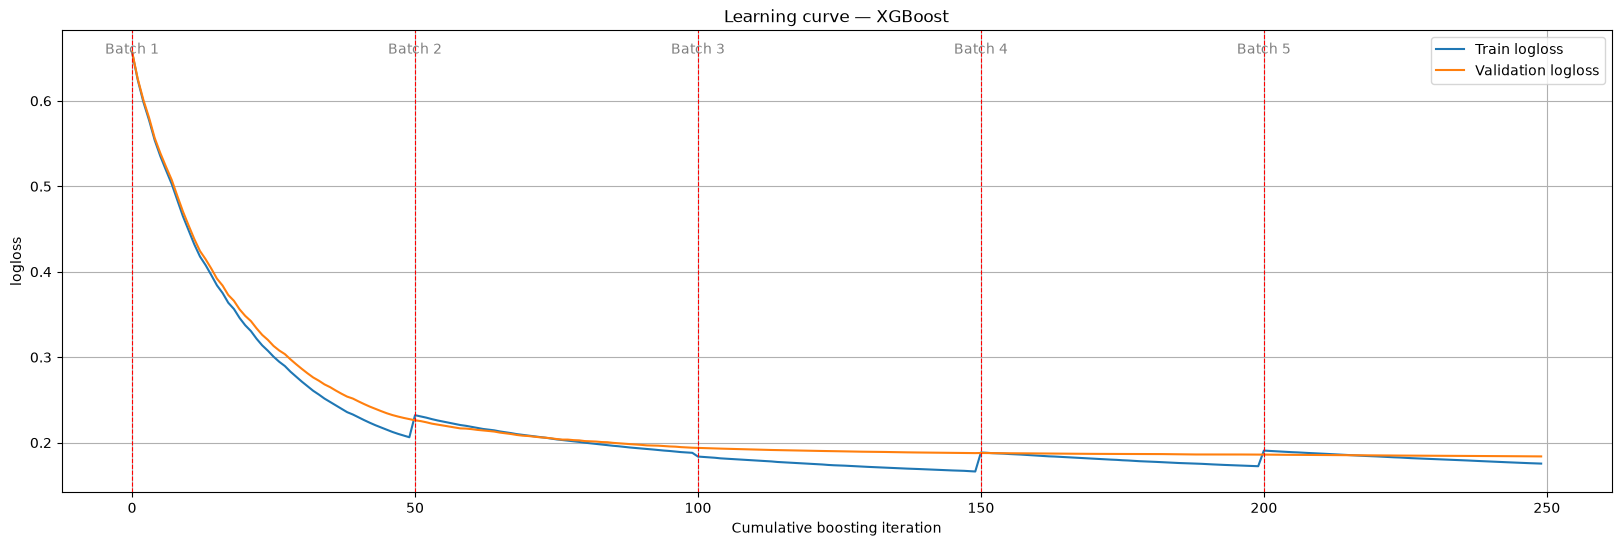

,batch,train_metric,validation_metric
0,1,0.206314,0.227488
1,2,0.188093,0.194062
2,3,0.166238,0.187762
3,4,0.172419,0.186086
4,5,0.175490,0.183885


In [8]:
# ==============================================================================
# 1. MODEL INITIALIZATION & TRAINING
# ==============================================================================
# Instantiate the trainer wrapper for XGBoost
xgboost_trainer = create_trainer("xgboost")

# Train the model using Spark DataFrames and specific hyperparameters
xgboost_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "objective": "binary:logistic",  # Binary classification using logistic regression
        "eval_metric": "logloss",         # Evaluation metric to minimize during training
        "n_estimators": 50,              # Number of boosting rounds (trees)
        "learning_rate": 0.05,           # Step size shrinkage to prevent overfitting
        "max_depth": 6,                  # Maximum depth of a tree
        "reg_lambda": 3.0,               # L2 regularization term on weights
        "subsample": 0.8,                # Ratio of training instances sampled per tree
        "colsample_bytree": 0.8,          # Subsample ratio of columns when constructing each tree
        "random_state": RANDOM_STATE,    # Seed for reproducibility
    },
    training_config=TRAINING_CONFIG,
    learning_rate_config=LEARNING_RATE_CONFIG,
)

# ==============================================================================
# 2. MODEL EXTRACTION & LOGGING
# ==============================================================================
# Retrieve the fully trained XGBoost model pipeline object
xgboost_model = xgboost_trainer.get_trained_model()

# Display the training logs and evaluation metrics history (e.g., loss curves)
display(summarize_history(xgboost_trainer))

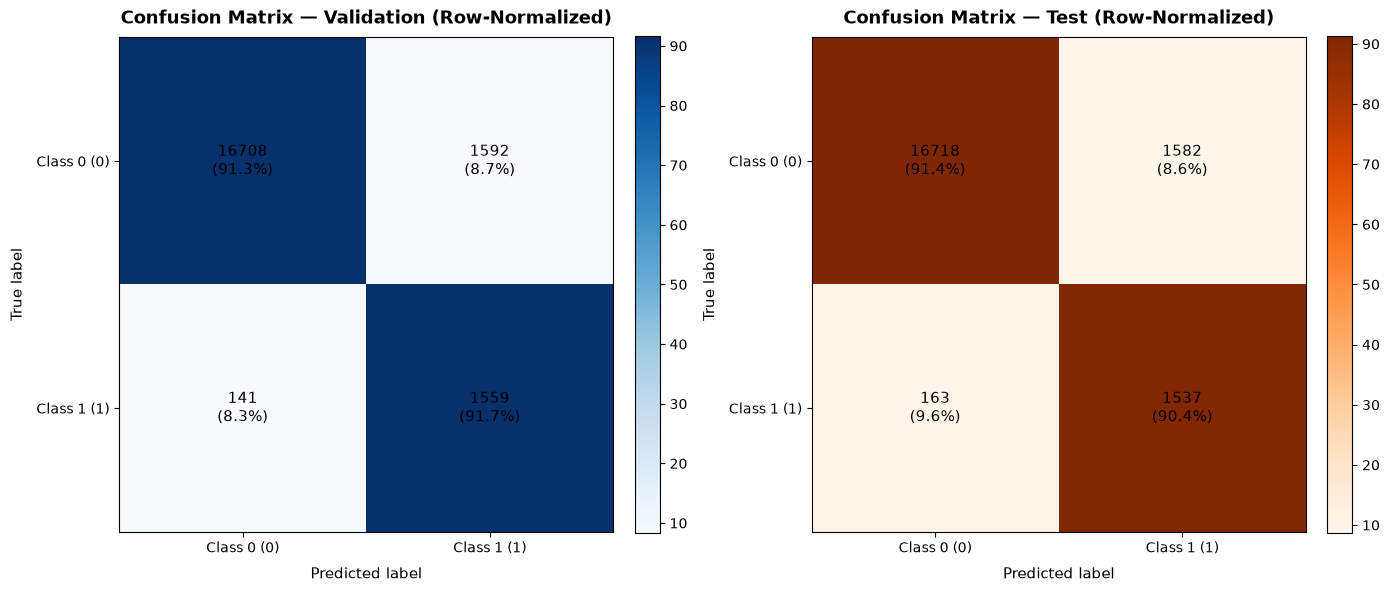

In [9]:
# ==============================================================================
# 1. MODEL PREDICTIONS
# ==============================================================================
# Use the trained XGBoost model to predict labels (classes) 
# for both the validation and test datasets.
y_pred_valid = xgboost_model.predict(X_valid)
y_pred_test  = xgboost_model.predict(X_test)

# ==============================================================================
# 2. RESULT STRUCTURING
# ==============================================================================
# Create DataFrames pairing the true values (ground truth) with the predicted 
# values to make performance analysis easier.
results_valid_df = make_results_df(y_valid, y_pred_valid)
results_test_df  = make_results_df(y_test, y_pred_test)

# ==============================================================================
# 3. VISUALIZATION (CONFUSION MATRIX)
# ==============================================================================
# Generate a side-by-side comparison of confusion matrices for validation and test.
# This helps visually assess true/false positives and true/false negatives.
plot_binary_confusion_matrices(
    results_valid_df,
    results_test_df,
    label_order=(0, 1),                           # Order of classes for the matrix
    class_labels=("Class 0 (0)", "Class 1 (1)")  # Custom labels for the axes
)

## Phase 7 — Train CatBoost

CatBoost receives the same Spark inputs and shared training controls. The trainer disables CatBoost's local training artifacts by default.

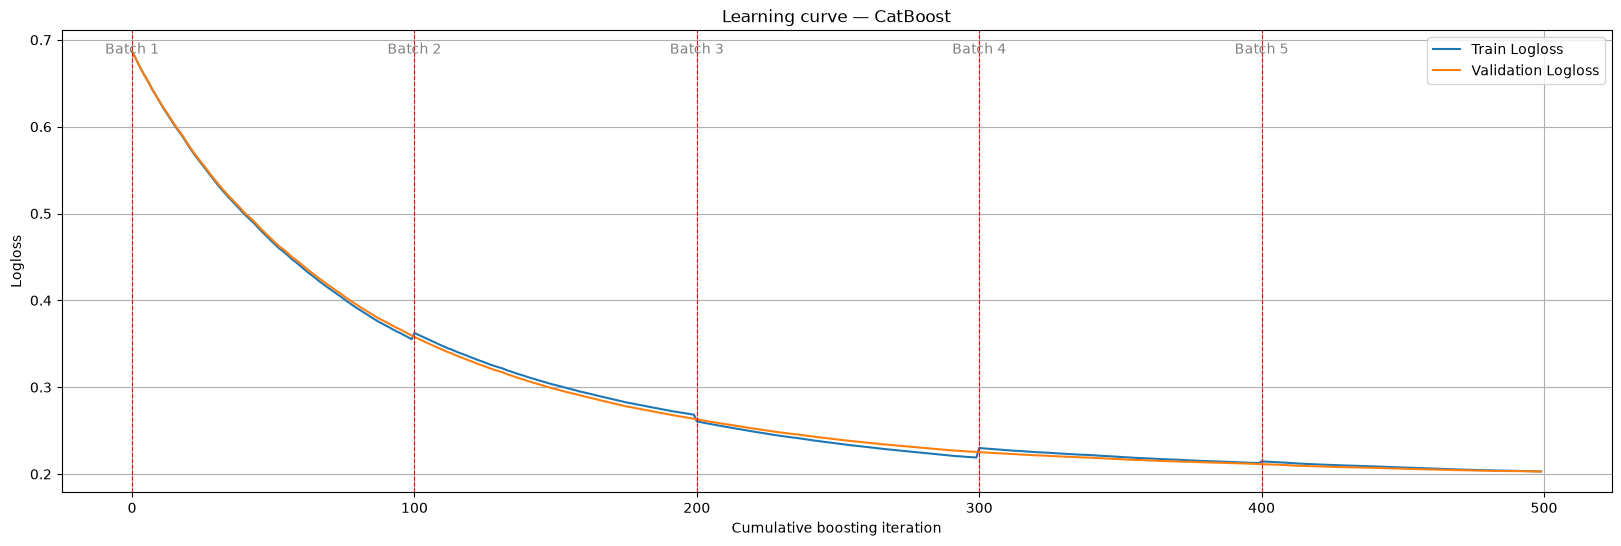

,batch,train_metric,validation_metric
0,1,0.355192,0.359455
1,2,0.268263,0.263713
2,3,0.218939,0.225373
3,4,0.212600,0.211572
4,5,0.202992,0.202912


In [10]:
# ==============================================================================
# 1. MODEL INITIALIZATION & TRAINING
# ==============================================================================
# Instantiate the trainer wrapper for CatBoost
catboost_trainer = create_trainer("catboost")

# Train the model using Spark DataFrames with optimized CatBoost hyperparameters
catboost_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "loss_function": "Logloss",        # Objective function optimized during training
        "eval_metric": "Logloss",          # Metric used on validation data for early stopping detection
        "iterations": 100,                 # Maximum number of trees to build
        "learning_rate": 0.01,             # Step size shrinkage to control convergence speed
        "depth": 6,                        # Depth of the trees
        "l2_leaf_reg": 3.0,                # L2 regularization term coefficient on leaf values
        "auto_class_weights": "Balanced",  # Automatically adjusts weights inversely proportional to class frequencies
        "bootstrap_type": "Bernoulli",     # Subsampling method for selecting data instances
        "subsample": 0.8,                  # Sample rate for bagging when Bernoulli bootstrap is active
        "random_seed": RANDOM_STATE,       # Seed used for reproducibility
        "verbose": False,                  # Disables detailed per-iteration logging console prints
    },
    # Merges global training config while explicitly forcing sample weights to False
    training_config={**TRAINING_CONFIG, "use_sample_weight": False},
)

# ==============================================================================
# 2. MODEL EXTRACTION & LOGGING
# ==============================================================================
# Retrieve the fully trained CatBoost model pipeline object
catboost_model = catboost_trainer.get_trained_model()

# Display the training logs and evaluation metrics history (e.g., loss curves)
display(summarize_history(catboost_trainer))

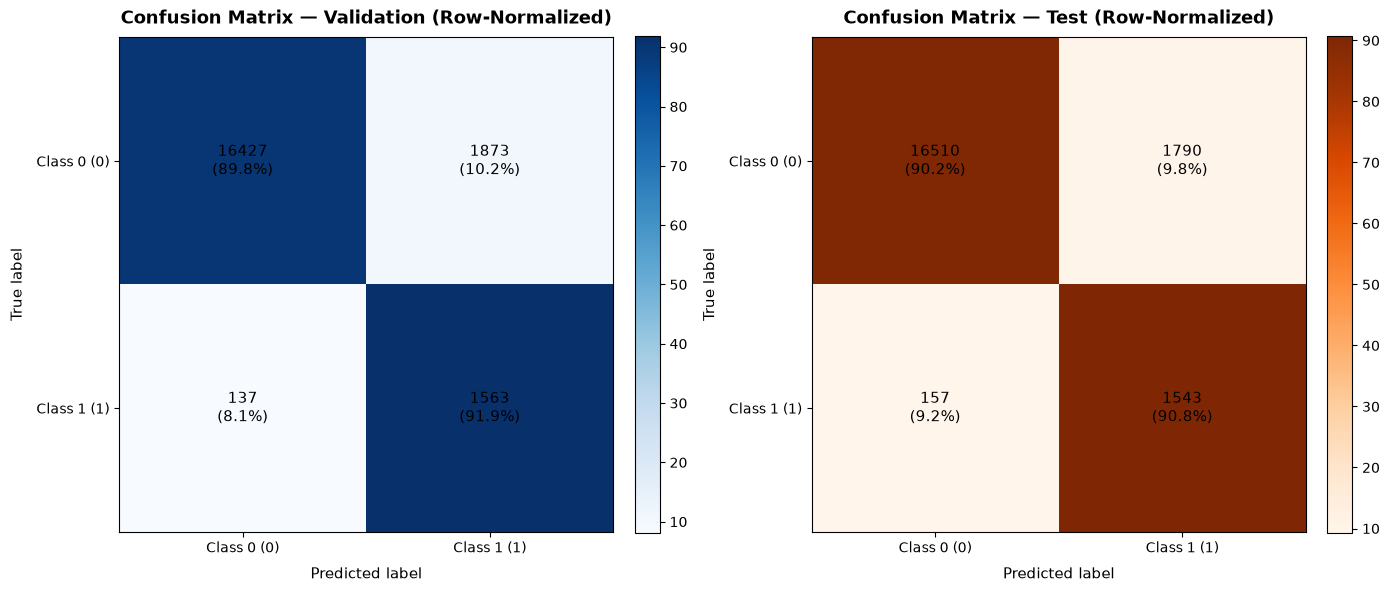

In [11]:
# ==============================================================================
# 1. MODEL PREDICTIONS
# ==============================================================================
# Use the trained Catboost model to predict labels (classes) 
# for both the validation and test datasets.
y_pred_valid = catboost_model.predict(X_valid)
y_pred_test  = catboost_model.predict(X_test)

# ==============================================================================
# 2. RESULT STRUCTURING
# ==============================================================================
# Create DataFrames pairing the true values (ground truth) with the predicted 
# values to make performance analysis easier.
results_valid_df = make_results_df(y_valid, y_pred_valid)
results_test_df  = make_results_df(y_test, y_pred_test)

# ==============================================================================
# 3. VISUALIZATION (CONFUSION MATRIX)
# ==============================================================================
# Generate a side-by-side comparison of confusion matrices for validation and test.
# This helps visually assess true/false positives and true/false negatives.
plot_binary_confusion_matrices(
    results_valid_df,
    results_test_df,
    label_order=(0, 1),                           # Order of classes for the matrix
    class_labels=("Class 0 (0)", "Class 1 (1)")  # Custom labels for the axes
)

## Phase 8 — Train LightGBM

LightGBM uses binary log loss and supports the same batch-level learning-rate policy as XGBoost.

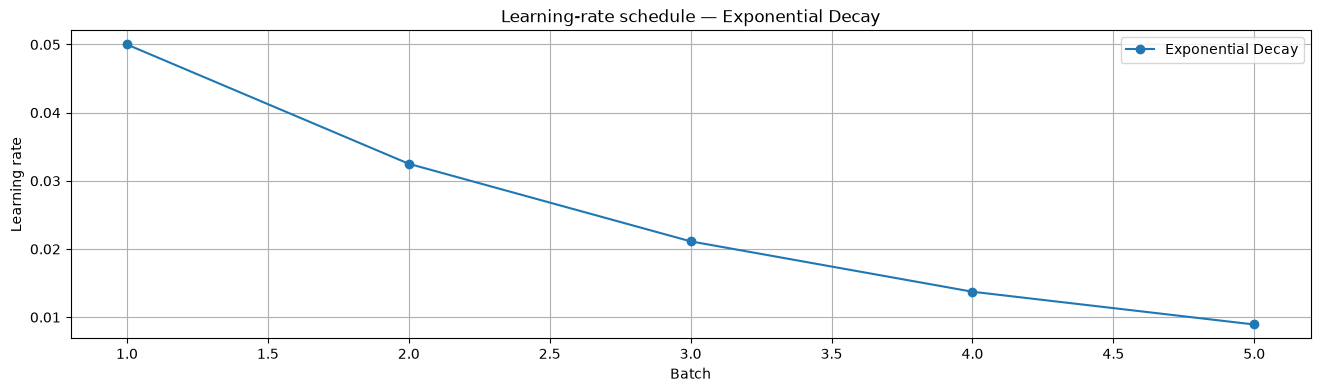

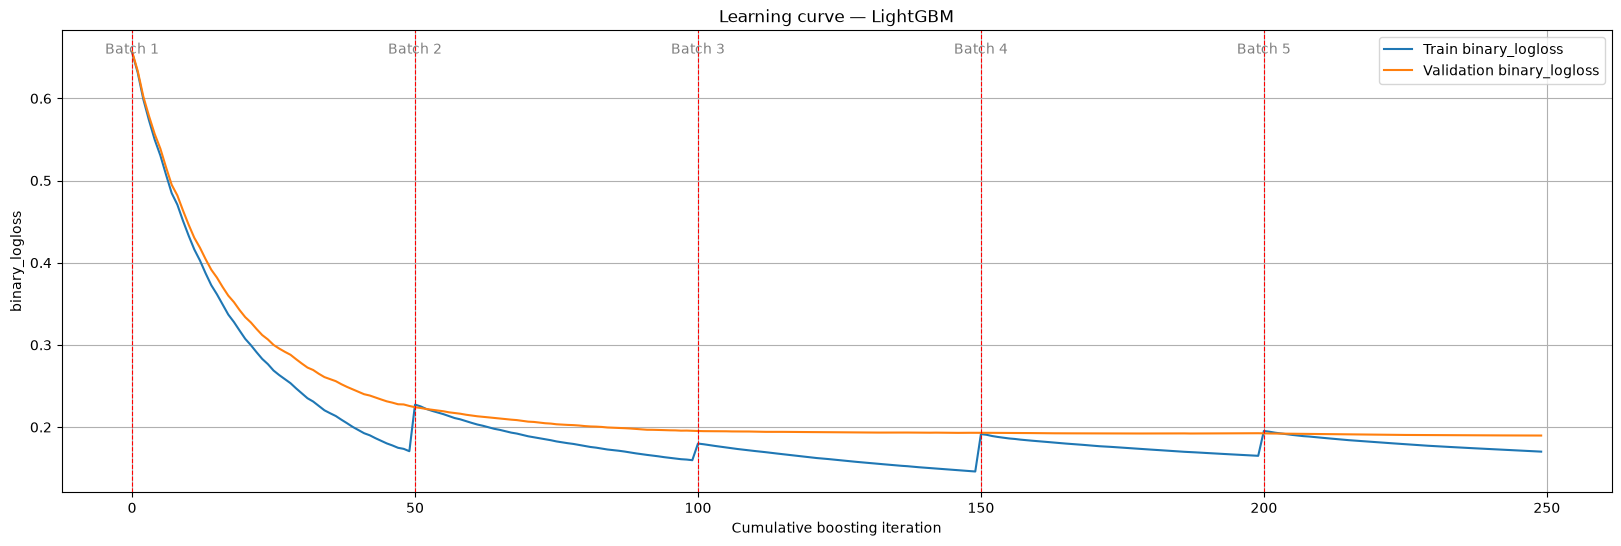

,batch,train_metric,validation_metric
0,1,0.170638,0.225703
1,2,0.159703,0.195425
2,3,0.145948,0.193061
3,4,0.165031,0.192522
4,5,0.170124,0.189709


In [12]:
# ==============================================================================
# 1. MODEL INITIALIZATION & TRAINING
# ==============================================================================
# Instantiate the trainer wrapper for LightGBM
lightgbm_trainer = create_trainer("lightgbm")

# Train the model using Spark DataFrames with optimized LightGBM hyperparameters
lightgbm_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "objective": "binary",            # Binary classification task
        "metric": "binary_logloss",       # Evaluation metric used to track validation loss
        "n_estimators": 50,               # Number of boosting iterations (trees)
        "learning_rate": 0.05,            # Shrinkage rate to scale each tree's contribution
        "num_leaves": 30,                 # Main parameter controlling tree complexity (max leaves per tree)
        "force_col_wise": True,           # Forces column-wise histogram building (efficient for small/medium datasets)
        "subsample": 0.8,                 # Percentage of rows randomly selected for training each tree
        "colsample_bytree": 0.8,          # Percentage of features randomly sampled for building each tree
        "random_state": RANDOM_STATE,    # Random seed ensuring deterministic results
        "verbosity": -1,                  # Disables all inner LightGBM warnings and info logs
    },
    training_config=TRAINING_CONFIG,
    learning_rate_config=LEARNING_RATE_CONFIG,
)

# ==============================================================================
# 2. MODEL EXTRACTION & LOGGING
# ==============================================================================
# Retrieve the fully trained LightGBM model pipeline object
lightgbm_model = lightgbm_trainer.get_trained_model()

# Display the training logs and evaluation metrics history (e.g., loss curves)
display(summarize_history(lightgbm_trainer))

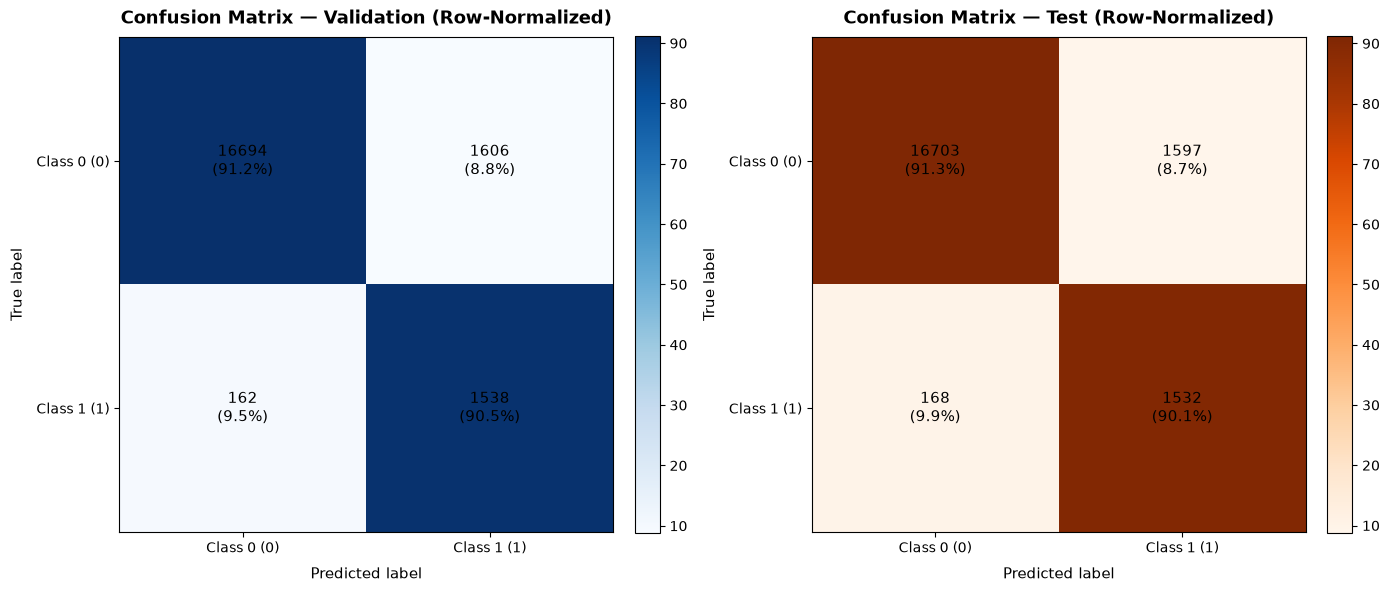

In [13]:
# ==============================================================================
# 1. MODEL PREDICTIONS
# ==============================================================================
# Use the trained LightGBM model to predict labels (classes) 
# for both the validation and test datasets.
y_pred_valid = lightgbm_model.predict(X_valid)
y_pred_test  = lightgbm_model.predict(X_test)

# ==============================================================================
# 2. RESULT STRUCTURING
# ==============================================================================
# Create DataFrames pairing the true values (ground truth) with the predicted 
# values to make performance analysis easier.
results_valid_df = make_results_df(y_valid, y_pred_valid)
results_test_df  = make_results_df(y_test, y_pred_test)

# ==============================================================================
# 3. VISUALIZATION (CONFUSION MATRIX)
# ==============================================================================
# Generate a side-by-side comparison of confusion matrices for validation and test.
# This helps visually assess true/false positives and true/false negatives.
plot_binary_confusion_matrices(
    results_valid_df,
    results_test_df,
    label_order=(0, 1),                           # Order of classes for the matrix
    class_labels=("Class 0 (0)", "Class 1 (1)")  # Custom labels for the axes
)

## Phase 9 — Final Validation and Test Comparison

The test set is used here to perform the final model comparison. To streamline the process, we use the unified `evaluate_models` function to evaluate our three trained champions (**XGBoost**, **CatBoost**, and **LightGBM**) side-by-side on both the validation and test datasets.

For each model, this pipeline will:
1. **Generate hard-label predictions** to evaluate classification correctness via confusion matrices.
2. **Structure actual vs. predicted values** into unified DataFrames.
3. **Plot comparative confusion matrices** to visually assess true/false positives and negatives on both validation and test sets.

```python
# Define the models to evaluate
trained_models = {
    "XGBoost": xgboost_model,
    "CatBoost": catboost_model,
    "LightGBM": lightgbm_model
}

# Run the unified evaluation pipeline
evaluate_models(
    models_dict=trained_models,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test
)

In [14]:
def evaluate_models(models_dict, X_valid, y_valid, X_test, y_test):
    """
    Loops through trained models, generates predictions, creates results DataFrames,
    and plots confusion matrices for both validation and test datasets.
    """
    for model_name, model_obj in models_dict.items():
        print("\n" + "="*80)
        print(f" STARTING EVALUATION FOR: {model_name.upper()} ".center(80, "#"))
        print("="*80)
        
        # 1. MODEL PREDICTIONS
        print(f"[{model_name.upper()}] Step 1: Generating predictions on Validation and Test sets...")
        y_pred_valid = model_obj.predict(X_valid)
        y_pred_test  = model_obj.predict(X_test)
        
        # 2. RESULT STRUCTURING
        print(f"[{model_name.upper()}] Step 2: Structuring results into DataFrames...")
        results_valid_df = make_results_df(y_valid, y_pred_valid)
        results_test_df  = make_results_df(y_test, y_pred_test)
        
        # 3. VISUALIZATION (CONFUSION MATRIX)
        print(f"[{model_name.upper()}] Step 3: Plotting Validation and Test confusion matrices...")
        plot_binary_confusion_matrices(
            results_valid_df,
            results_test_df,
            label_order=(0, 1),
            class_labels=("Class 0 (0)", "Class 1 (1)")
        )
        
        print(f" {'FINISHED ' + model_name.upper() + ' EVALUATION'} ".center(80, "-"))
        print("\n")


####################### STARTING EVALUATION FOR: XGBOOST #######################
[XGBOOST] Step 1: Generating predictions on Validation and Test sets...
[XGBOOST] Step 2: Structuring results into DataFrames...
[XGBOOST] Step 3: Plotting Validation and Test confusion matrices...


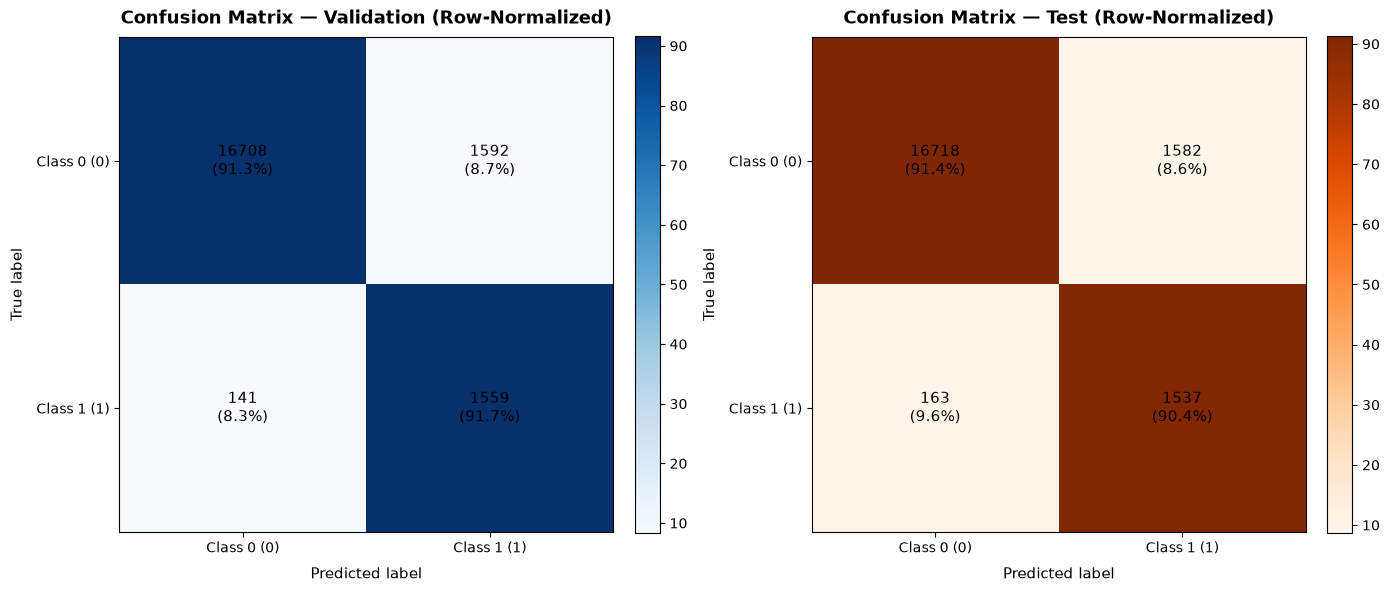

------------------------- FINISHED XGBOOST EVALUATION --------------------------



###################### STARTING EVALUATION FOR: CATBOOST #######################
[CATBOOST] Step 1: Generating predictions on Validation and Test sets...
[CATBOOST] Step 2: Structuring results into DataFrames...
[CATBOOST] Step 3: Plotting Validation and Test confusion matrices...


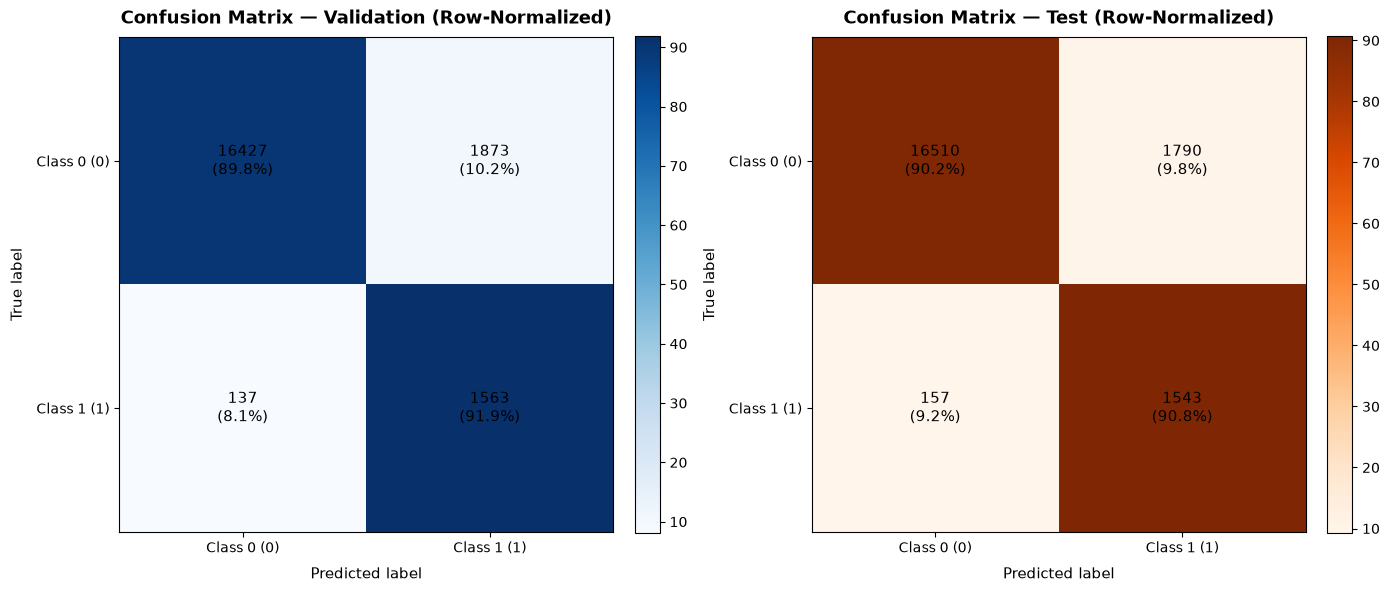

------------------------- FINISHED CATBOOST EVALUATION -------------------------



###################### STARTING EVALUATION FOR: LIGHTGBM #######################
[LIGHTGBM] Step 1: Generating predictions on Validation and Test sets...
[LIGHTGBM] Step 2: Structuring results into DataFrames...
[LIGHTGBM] Step 3: Plotting Validation and Test confusion matrices...


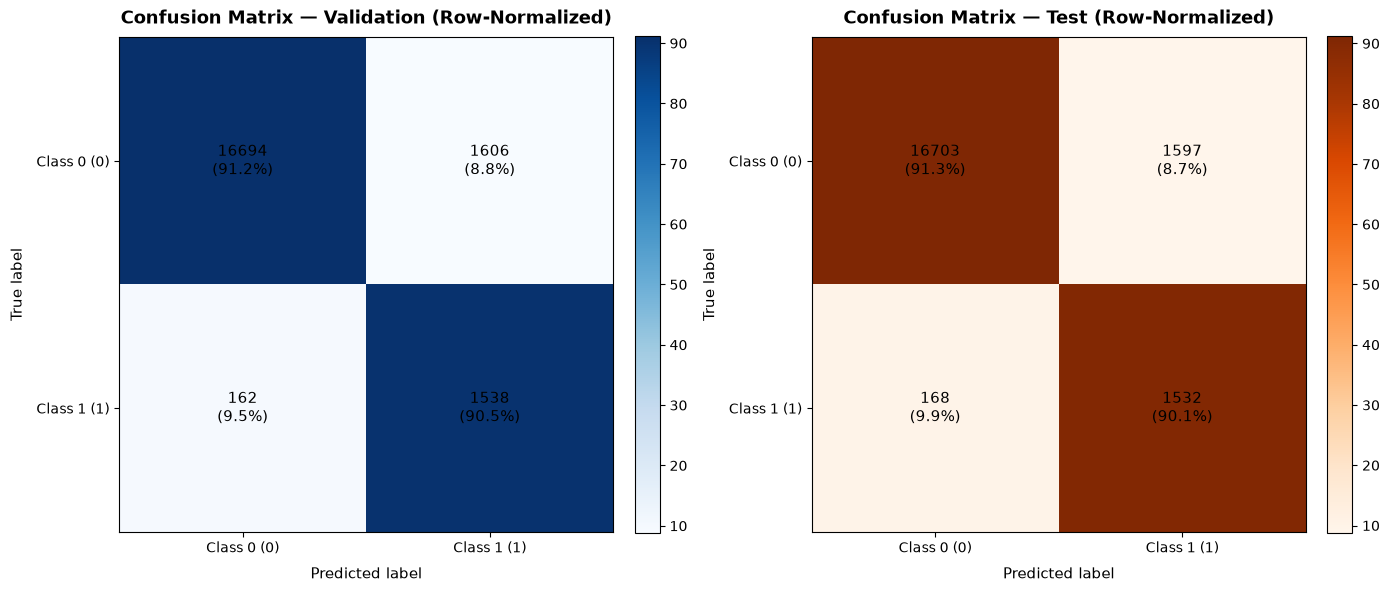

------------------------- FINISHED LIGHTGBM EVALUATION -------------------------




In [15]:
# Define the models to evaluate
trained_models = {
    "XGBoost": xgboost_model,
    "CatBoost": catboost_model,
    "LightGBM": lightgbm_model
}

# Run the unified evaluation pipeline
evaluate_models(
    models_dict=trained_models,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test
)

### Interpretation guidance

Do not select a model from one metric alone. Check whether validation and test behavior are consistent, inspect minority-class errors, and consider probability calibration when scores drive downstream decisions. The three runs are a workflow demonstration, not a complete hyperparameter search.

## Phase 10 — Resource cleanup

Stop the local Spark session explicitly when the notebook no longer needs it.

In [16]:
spark.stop()

## Next steps

For a production experiment, remove or increase `MAX_ROWS` only after measuring driver memory, record all configurations and package versions, add calibrated probability evaluation, and persist the selected native model with its backend SDK.